In [289]:
import numpy as np
from sympy import symbols, Matrix
import cv2
import matplotlib.pyplot as plt
import open3d as o3d
from scipy.optimize import minimize
from sklearn.preprocessing import PolynomialFeatures
import os

In [249]:
np.set_printoptions(precision=2, floatmode='maxprec', suppress=False)
figures_dir = "/Users/piotrblaszyk/Documents/university/MRIGI/igi-70004/cw-2/figures/"

def skew_symmetric(t):
    return np.array([
        [0, -t[2, 0], t[1, 0]],
        [t[2, 0], 0, -t[0, 0]],
        [-t[1, 0], t[0, 0], 0]
    ])

def normalise(x, w, h):
    homogenous_x = np.hstack([x, 1])
    y = np.array([[2 / w, 0, -1], [0, 2 / h, -1], [0, 0, 1]])
    res = y @ homogenous_x
    res = np.ravel(res)
    res /= res[2]
    res_2d = res[:2]
    return res_2d

foo = normalise([1, 2], 10, 20)
print(foo)

[-0.8 -0.8]


data from pdf

In [250]:
k1 = np.array([
    [1.02408777e+03, 0., 6.01806702e+02],
    [0., 1.02389478e+03, 5.08131683e+02],
    [0., 0., 1. ]
])
k2 = np.array([
    [1.02419836e+03, 0., 6.96750427e+02],
    [0., 1.02398749e+03, 5.07494263e+02],
    [0., 0., 1.]
])
r = np.array([
    [9.99999404e-01, -1.24090354e-06, -1.11142127e-03],
    [1.29263049e-06, 1., 4.65405355e-05],
    [1.11142127e-03, -4.65419434e-05, 9.99999404e-01]
])
t = np.array([
    [-4.34818459e+00],
    [2.83603016e-02],
    [-9.00963729e-04]
])
rt = np.hstack((r, t))
print(rt)

d1 =  np.array([ -2.52257544e-03, 4.38565714e-03, 0., 0., 9.21500759e-05 ])
d2 =  np.array([ -3.26306466e-03, 5.70008671e-03, 0., 0., 7.57322850e-05 ])

[[ 1.00e+00 -1.24e-06 -1.11e-03 -4.35e+00]
 [ 1.29e-06  1.00e+00  4.65e-05  2.84e-02]
 [ 1.11e-03 -4.65e-05  1.00e+00 -9.01e-04]]


Task 2 (ii)

In [251]:
d = symbols('d')
rt = Matrix([[0, 1, 0, 0], [0, 0, 1, -d], [1, 0, 0, 6 * d]])
k = Matrix([[800, 0, 350], [0, 720, 250], [0, 0, 1]])
origin = Matrix([0, 0, 0, 1])
origin_camera = k * rt * origin
origin_camera_scaled = origin_camera / origin_camera[2]
print(origin_camera)
print(origin_camera_scaled)

Matrix([[2100*d], [780*d], [6*d]])
Matrix([[350], [130], [1]])


Task 3

(a)

1024 1280
1024 1280


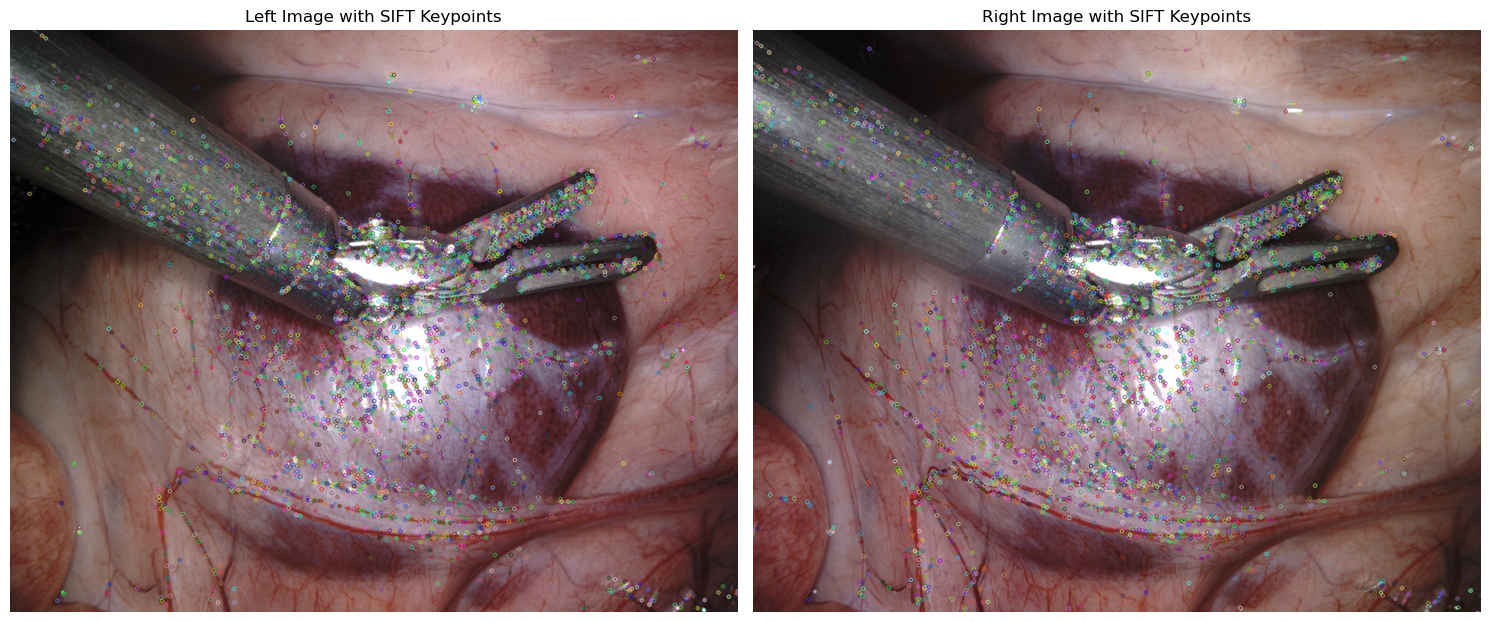

(-0.5, 1279.5, 511.5, -0.5)

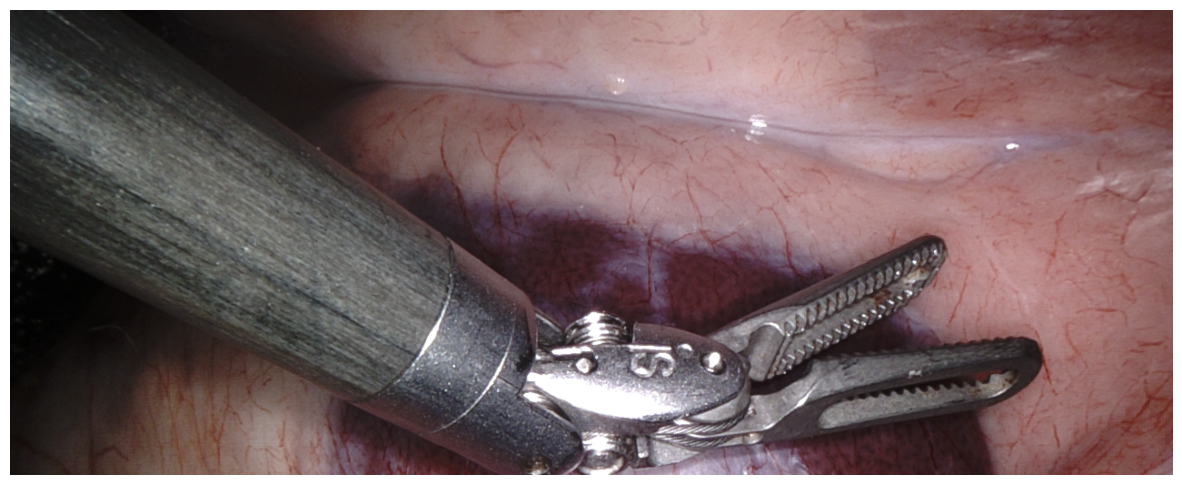

In [252]:
prefix = '/Users/piotrblaszyk/Documents/university/MRIGI/igi-70004/cw-2/task-3-data/'
# Load the stereo images
distorted_left_image_rgb = cv2.imread(f'{prefix}left.png', cv2.IMREAD_COLOR)
distorted_right_image_rgb = cv2.imread(f'{prefix}right.png', cv2.IMREAD_COLOR)
left_shape = distorted_left_image_rgb.shape[:2]
right_shape = distorted_right_image_rgb.shape[:2]
left_height, left_width = left_shape
right_height, right_width = right_shape
print(left_height, left_width)
print(right_height, right_width)
# plt.figure(figsize=(15, 10))
# plt.imshow(cv2.cvtColor(distorted_left_image_rgb, cv2.COLOR_BGR2RGB))
# plt.axis('off')
# left_image_rgb = cv2.undistort(distorted_left_image_rgb, k1, d1)
# right_image_rgb = cv2.undistort(distorted_right_image_rgb, k2, d2)
# plt.figure(figsize=(15, 10))
# plt.imshow(cv2.cvtColor(left_image_rgb, cv2.COLOR_BGR2RGB))
# plt.axis('off')
left_image_rgb = distorted_left_image_rgb
right_image_rgb = distorted_right_image_rgb
left_image_gray = cv2.cvtColor(left_image_rgb, cv2.COLOR_BGR2GRAY)
right_image_gray = cv2.cvtColor(right_image_rgb, cv2.COLOR_BGR2GRAY)

# Check if the images are loaded correctly
if left_image_gray is None or right_image_gray is None:
    raise ValueError("One or both images could not be loaded. Check the file paths.")

# Initialize the SIFT detector
sift = cv2.SIFT_create()

# Detect keypoints and compute descriptors
keypoints_left, descriptors_left = sift.detectAndCompute(left_image_gray, None)
keypoints_right, descriptors_right = sift.detectAndCompute(right_image_gray, None)

# Draw the keypoints on the images
left_image_with_keypoints = cv2.drawKeypoints(left_image_rgb, keypoints_left, None)
right_image_with_keypoints = cv2.drawKeypoints(right_image_rgb, keypoints_right, None)

# Plot the images with keypoints
plt.figure(figsize=(15, 10))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(left_image_with_keypoints, cv2.COLOR_BGR2RGB))
plt.title('Left Image with SIFT Keypoints')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(right_image_with_keypoints, cv2.COLOR_BGR2RGB))
plt.title('Right Image with SIFT Keypoints')
plt.axis('off')

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 10))
plt.imshow(cv2.cvtColor(left_image_rgb[:512, :], cv2.COLOR_BGR2RGB))
plt.axis('off')

(b)

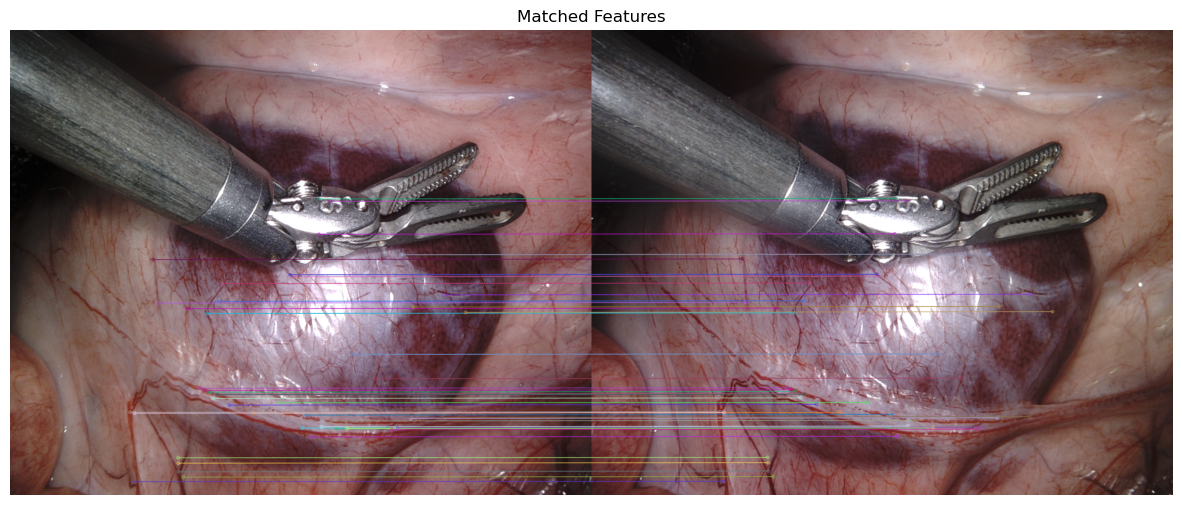

In [253]:
# bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
# matches = bf.match(descriptors_left, descriptors_right)

# Match descriptors using BFMatcher with k=2 to get the two nearest matches
bf = cv2.BFMatcher(cv2.NORM_L2)
knn_matches = bf.knnMatch(descriptors_left, descriptors_right, k=2)

# Apply the ratio test
ratio_thresh = 0.75
matches = [m for m, n in knn_matches if m.distance < ratio_thresh * n.distance]

# Sort matches by distance (best matches first)
matches = sorted(matches, key=lambda x: x.distance)

# Select the top N matches for visualization
num_matches = 50
good_matches = matches[:num_matches]

# Draw matches using OpenCV's built-in function
matched_image = cv2.drawMatches(left_image_rgb, keypoints_left, right_image_rgb, keypoints_right, good_matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Display the result
plt.figure(figsize=(15, 10))
plt.imshow(cv2.cvtColor(matched_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Matched Features')
plt.show()

(c)

fundamental matrix from stereo

Fundamental Matrix:
 [[ 2.78e-07 -8.79e-05  2.63e-02]
 [ 8.91e-05  3.41e-06 -2.49e-01]
 [-2.75e-02  2.45e-01  1.00e+00]]


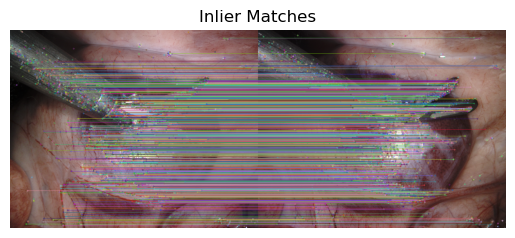

In [254]:
# Suppose `matches` is a sorted list of DMatch objects
# `keypoints_left` and `keypoints_right` are the keypoints from the two images

# Extract points from the matches
pts_left = np.float32([keypoints_left[m.queryIdx].pt for m in matches])
pts_right = np.float32([keypoints_right[m.trainIdx].pt for m in matches])

fundamental_matrix, inliers = cv2.findFundamentalMat(pts_left, pts_right, method=cv2.FM_RANSAC)
print("Fundamental Matrix:\n", fundamental_matrix)
inlier_matches = [matches[i] for i in range(len(matches)) if inliers[i]]
result_image = cv2.drawMatches(left_image_rgb, keypoints_left, right_image_rgb, keypoints_right, inlier_matches, None)

plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Inlier Matches')
plt.show()

fundamental matrix from camera parameters (ChatGPT)

In [255]:
# Compute the skew-symmetric matrix of t
t_skew = skew_symmetric(t)

# Compute the fundamental matrix
f = np.linalg.inv(k2).T @ t_skew @ r @ np.linalg.inv(k1)

# Normalize f for consistency
f /= f[-1, -1]

print("Fundamental Matrix (ChatGPT):")
print(f)

Fundamental Matrix (ChatGPT):
[[ 1.98e-08  5.65e-07  1.79e-02]
 [ 2.47e-06 -1.27e-07  2.79e+00]
 [-1.95e-02 -2.79e+00  1.00e+00]]


fundamental matrix from camera parameters (lecture slides)

In [256]:
f_mine = skew_symmetric(k2 @ t) @ k2 @ r @ np.linalg.inv(k1)

f_mine /= f_mine[-1, -1]

print("Fundamental Matrix (lecture slides):")
print(f_mine)

Fundamental Matrix (lecture slides):
[[ 1.98e-08  5.65e-07  1.79e-02]
 [ 2.47e-06 -1.27e-07  2.79e+00]
 [-1.95e-02 -2.79e+00  1.00e+00]]


compare fundamental matrices

In [257]:
ratio = fundamental_matrix / f_mine
print(ratio)

[[ 1.41e+01 -1.56e+02  1.47e+00]
 [ 3.61e+01 -2.68e+01 -8.91e-02]
 [ 1.41e+00 -8.77e-02  1.00e+00]]


(d)

In [258]:
# Convert points to homogeneous coordinates
pts_left_h = np.hstack((pts_left, np.ones((pts_left.shape[0], 1))))  # Shape: (N, 3)
pts_right_h = np.hstack((pts_right, np.ones((pts_right.shape[0], 1))))  # Shape: (N, 3)

# Compute the epipolar constraint for each pair: point_right.T * F * point_left
# (1, 3) x (3, 3) x (3, 1) = scalar for each point pair
epipolar_constraint = np.einsum('ij,jk,ik->i', pts_right_h, fundamental_matrix, pts_left_h)

# Perform element-wise check if values are close to zero
tolerance = 1e-3  # Adjust tolerance based on your requirements
epipolar_mask = np.isclose(epipolar_constraint, 0, atol=tolerance)

print(epipolar_constraint)
print(epipolar_mask)
print("all", len(epipolar_mask))
print("epipolar", len([x for x in epipolar_mask if x]))
print("non-epipolar", len([x for x in epipolar_mask if not x]))

pts_left_epipolar = pts_left[epipolar_mask]
pts_right_epipolar = pts_right[epipolar_mask]

print(len(pts_left_epipolar))
print(len(pts_right_epipolar))

[ 0.12  0.16  0.09 ...  0.15 -0.13 -0.2 ]
[False False False ... False False False]
all 1362
epipolar 12
non-epipolar 1350
12
12


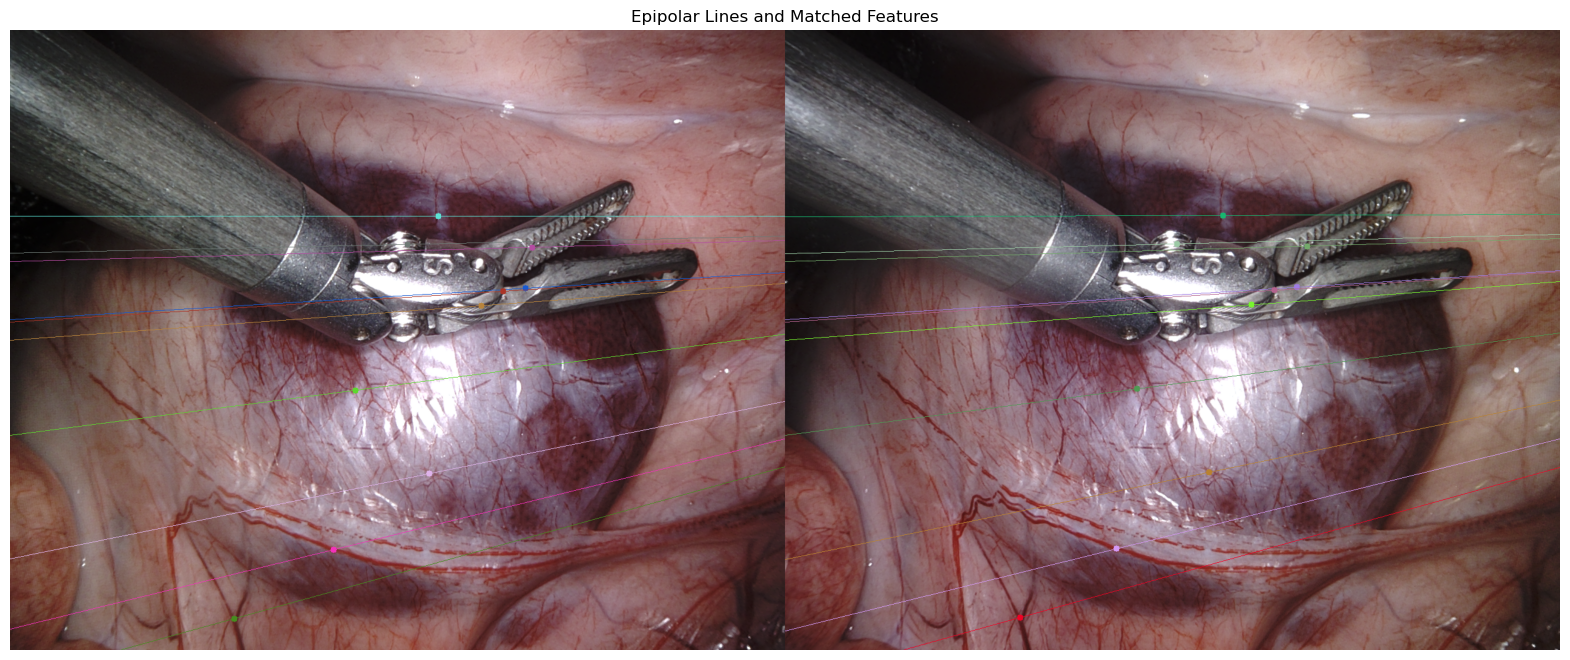

In [259]:
# Draw epipolar lines and matched points
def draw_epilines(img1, img2, lines, pts1, pts2):
    """ Draw epilines on images. Lines are drawn on img1 corresponding to pts2 and vice versa. """
    img1_copy = img1.copy()
    img2_copy = img2.copy()
    for r, pt1, pt2 in zip(lines, pts1, pts2):
        color = tuple(np.random.randint(0, 255, 3).tolist())
        x0, y0 = map(int, [0, -r[2] / r[1]])
        x1, y1 = map(int, [img1.shape[1], -(r[2] + r[0] * img1.shape[1]) / r[1]])
        img1_copy = cv2.line(img1_copy, (x0, y0), (x1, y1), color, 1)
        img1_copy = cv2.circle(img1_copy, tuple(np.int32(pt1)), 5, color, -1)
        img2_copy = cv2.circle(img2_copy, tuple(np.int32(pt2)), 5, color, -1)
    return img1_copy, img2_copy

# Compute epilines for points in the right image (for the left image)
lines_left = cv2.computeCorrespondEpilines(pts_right_epipolar.reshape(-1, 1, 2), 2, fundamental_matrix)
lines_left = lines_left.reshape(-1, 3)
img_left_with_lines, img_right_with_points = draw_epilines(left_image_rgb, right_image_rgb, lines_left, pts_left_epipolar, pts_right_epipolar)

# Compute epilines for points in the left image (for the right image)
lines_right = cv2.computeCorrespondEpilines(pts_left_epipolar.reshape(-1, 1, 2), 1, fundamental_matrix)
lines_right = lines_right.reshape(-1, 3)
img_right_with_lines, img_left_with_points = draw_epilines(right_image_rgb, left_image_rgb, lines_right, pts_right_epipolar, pts_left_epipolar)

# Concatenate images for visualization
concatenated_img = np.hstack((img_left_with_lines, img_right_with_lines))

# Display the result
plt.figure(figsize=(20, 10))
plt.imshow(cv2.cvtColor(concatenated_img, cv2.COLOR_BGR2RGB))
plt.title("Epipolar Lines and Matched Features")
plt.axis("off")
plt.show()


(e)

Disparity map

/var/folders/5k/c8g3ybm11m10k2w6qd7yvrlc0000gn/T/ipykernel_72017/77737875.py:17: RuntimeWarning: divide by zero encountered in divide
  depths = k1[0, 0] * np.linalg.norm(t) / disparity


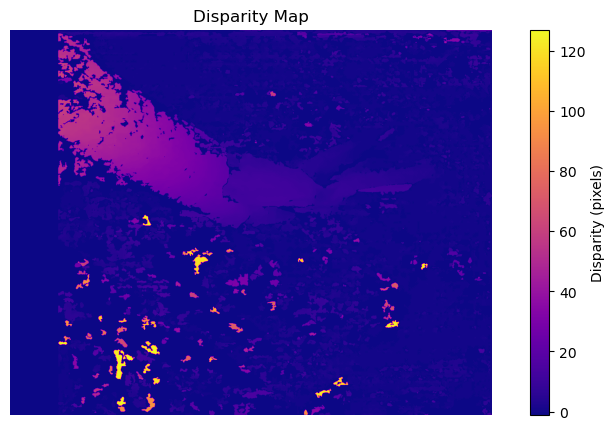

In [282]:
# Create a stereo block matching object
# StereoBM is faster but less accurate; StereoSGBM is more accurate but computationally expensive
stereo = cv2.StereoSGBM_create(
    minDisparity=0,
    numDisparities=16 * 8,  # Must be divisible by 16
    blockSize=9,  # Size of the matching block
    P1=8 * 3 * 9**2,  # Penalty for disparity smoothness (based on block size)
    P2=32 * 3 * 9**2,  # Larger penalty for larger disparities
    disp12MaxDiff=1,
    uniquenessRatio=15,
    speckleWindowSize=100,
    speckleRange=32
)

# Compute the disparity map
disparity = stereo.compute(left_image_gray, right_image_gray).astype(np.float32) / 16.0
depths = k1[0, 0] * np.linalg.norm(t) / disparity

# Normalize the disparity map for visualization
disparity_normalized = cv2.normalize(disparity, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)

# Display the disparity map
plt.figure(figsize=(10, 5))
plt.imshow(disparity, cmap='plasma')
plt.colorbar(label="Disparity (pixels)")
plt.title("Disparity Map")
plt.axis("off")
plt.show()


3D surface reconstruction

In [261]:
# pixspy
# (width, height)
# top-left corner is origin

circle_2d_coords = np.array([
    [406, 422],
    [421, 410],
    [437, 394],
    [455, 372],

    [467, 349],
    [477, 325],
    [484, 305],
    [486, 283],
])

# opencv
# (height, width)
# top-left corner is origin

print(disparity.shape)
circle_disparities = [disparity[x[1], x[0]] for x in circle_2d_coords]
print(circle_disparities)
print()

R1, R2, P1, P2, Q, _, _ = cv2.stereoRectify(k1, d1, k2, d2, left_shape, r, t)
points_3D = cv2.reprojectImageTo3D(disparity, Q)
flattened_points_3D = points_3D.reshape(-1, points_3D.shape[2])
print(points_3D.shape)
print()
circle_points_3D = np.array([points_3D[x[1], x[0]] for x in circle_2d_coords])
print(circle_points_3D.shape)
for x in circle_points_3D:
    print(x)

(1024, 1280)
[27.875, 29.3125, 30.0, 30.875, 30.9375, 30.0, 28.625, 27.9375]

(1024, 1280, 3)

(8, 3)
[-38.09 -13.6  159.73]
[-33.99 -14.72 151.89]
[-30.9  -16.7  148.41]
[-27.49 -19.32 144.21]
[-25.74 -22.52 143.92]
[-25.1  -26.7  148.41]
[-25.24 -31.02 155.54]
[-25.55 -35.21 159.37]


In [262]:
point_cloud = o3d.geometry.PointCloud()
point_cloud.points = o3d.utility.Vector3dVector(circle_points_3D)
o3d.visualization.draw_geometries([point_cloud])

In [263]:
def sample_circle_3D(fit_result, num_points=100):
    """
    Sample evenly spaced points on a 3D circle.
    
    Args:
        fit_result (dict): Output of fit_circle_3D containing center, radius, and normal vector.
        num_points (int): Number of points to sample.

    Returns:
        numpy.ndarray: Array of shape (num_points, 3) containing 3D points on the circle.
    """
    center = fit_result["center"]
    radius = fit_result["radius"]
    normal = fit_result["normal"]

    # Generate 100 evenly spaced angles
    angles = np.linspace(0, 2 * np.pi, num_points, endpoint=False)

    # Create two orthogonal vectors in the plane of the circle
    # Find a vector not parallel to the normal
    arbitrary_vector = np.array([1, 0, 0]) if abs(normal[0]) < 0.9 else np.array([0, 1, 0])
    v1 = np.cross(normal, arbitrary_vector)
    v1 /= np.linalg.norm(v1)  # Normalize
    v2 = np.cross(normal, v1)  # Second orthogonal vector
    v2 /= np.linalg.norm(v2)  # Normalize

    # Compute points in 3D
    circle_points = []
    for angle in angles:
        point = center + radius * (np.cos(angle) * v1 + np.sin(angle) * v2)
        circle_points.append(point)

    return np.array(circle_points)


In [264]:
# circle_points_3D is an (n x 3) array where each row is a 3D point

# Step 1: Compute the centroid of the points
centroid = np.mean(circle_points_3D, axis=0)

# Step 2: Subtract the centroid from the points
centered_points = circle_points_3D - centroid

# Step 3: Compute the covariance matrix
cov_matrix = np.cov(centered_points.T)

# Step 4: Perform Singular Value Decomposition (SVD)
_, _, vh = np.linalg.svd(cov_matrix)

# The normal vector to the plane is the last row of vh (since it's the smallest singular value)
normal_vector = vh[-1]

# Step 5: The equation of the plane is: normal_vector[0] * x + normal_vector[1] * y + normal_vector[2] * z = d
# where (x, y, z) are points on the plane and d is the dot product of the normal vector and the centroid
d = np.dot(normal_vector, centroid)

# Output: normal vector and plane equation
print("Normal vector:", normal_vector)
print("Plane equation: {} * x + {} * y + {} * z = {}".format(normal_vector[0], normal_vector[1], normal_vector[2], d))

# [0.79 0.49 0.37]

Normal vector: [0.8  0.47 0.37]
Plane equation: 0.7989651958611256 * x + 0.4742691342721048 * y + 0.36976127985415397 * z = 22.156712324284655


In [265]:
def distance_point_to_plane(point, plane_normal, D):
    """
    Calculate the distance from a point to a plane.

    :param point: Point (x, y, z) as a numpy array or list
    :param plane_normal: Normal vector to the plane (A, B, C) as a numpy array or list
    :param D: The constant D from the plane equation Ax + By + Cz + D = 0
    :return: Distance from the point to the plane
    """
    point = np.array(point)
    plane_normal = np.array(plane_normal)
    
    # Compute the numerator (dot product of the point and plane normal + D)
    numerator = np.abs(np.dot(plane_normal, point) + D)
    
    # Compute the denominator (norm of the plane normal)
    denominator = np.linalg.norm(plane_normal)
    
    # Return the distance
    return numerator / denominator


In [280]:
def fit_circle_3D_ransac(points, num_iterations=100, distance_threshold=0.05):
    """
    Fit a 3D circle to a set of points in 3D space using RANSAC.
    
    Args:
        points (numpy.ndarray): Array of shape (n, 3) representing 3D points.
        num_iterations (int): The number of RANSAC iterations.
        distance_threshold (float): The threshold distance for considering a point as an inlier.
    
    Returns:
        dict: A dictionary with the circle's center, radius, and normal vector.
    """
    def fit_circle(points_subset):
        """
        Fit a circle to a subset of 3D points.
        Args:
            points_subset (numpy.ndarray): Subset of 3D points.
        Returns:
            tuple: center, radius of the fitted circle.
        """
        centroid = np.mean(points_subset, axis=0)
        initial_guess = np.hstack((centroid, 1.0))  # [x_center, y_center, z_center, radius]

        def cost_function(params):
            center = params[:3]  # Center of the circle
            radius = params[3]  # Radius of the circle
            plane_distances = np.array([distance_point_to_plane(x, normal_vector, -d) for x in points])
            distances_to_centre = np.linalg.norm(points_subset - center, axis=1)  # Distances from points to the center
            return np.sum((distances_to_centre - radius) ** 2) + np.sum(plane_distances ** 4)

        result = minimize(cost_function, initial_guess, method='BFGS')
        center, radius = result.x[:3], result.x[3]
        return center, radius

    best_inliers_count = 0
    best_circle = None

    for _ in range(num_iterations):
        # Randomly sample a subset of points (at least 3 points for a 3D circle)
        sample_indices = np.random.choice(points.shape[0], 3, replace=False)
        points_subset = points[sample_indices]

        # Fit a circle to this subset of points
        center, radius = fit_circle(points_subset)

        # Calculate the inliers (points that are close to the fitted circle)
        distances = np.linalg.norm(points - center, axis=1)  # Distances from points to the center
        inliers = np.abs(distances - radius) < distance_threshold

        inliers_count = np.sum(inliers)

        if inliers_count > best_inliers_count:
            best_inliers_count = inliers_count
            best_circle = {
                'center': center,
                'radius': radius,
                'inliers': points[inliers]
            }

    # Compute the normal vector of the fitted circle (using SVD on the inliers)
    inlier_points = best_circle['inliers']
    _, _, vh = np.linalg.svd(inlier_points - best_circle['center'])
    normal = vh[2]  # The normal vector is the last singular vector

    best_circle['normal'] = normal
    return best_circle

# Example usage:
# Assuming you have your 3D points stored in a variable `circle_points_3D` (n x 3 numpy array)
result = fit_circle_3D_ransac(circle_points_3D, num_iterations=100, distance_threshold=0.05)

print(f"Center: {result['center']}")
print(f"Radius: {result['radius']}")
print(f"Diameter: {result['radius'] * 2}")
print(f"Normal: {result['normal']}")
print()
print("Plane normal:", normal_vector)


Center: [-28.06 -23.86 151.96]
Radius: 8.484043462911496
Diameter: 16.96808692582299
Normal: [-0.82 -0.48 -0.32]

Plane normal: [0.8  0.47 0.37]


In [281]:
circle_points = sample_circle_3D(result, 16)
print("Sampled points shape:", circle_points.shape)

point_cloud = o3d.geometry.PointCloud()
point_cloud.points = o3d.utility.Vector3dVector(np.concatenate((circle_points_3D, circle_points), axis=0))
red_color = np.array([[1, 0, 0] for _ in range(len(circle_points_3D))])
blue_color = np.array([[0, 0, 1] for _ in range(len(circle_points))])
point_cloud.colors = o3d.utility.Vector3dVector(np.concatenate((red_color, blue_color), axis=0))
o3d.visualization.draw_geometries([point_cloud])

Sampled points shape: (16, 3)


Task 4

(a)

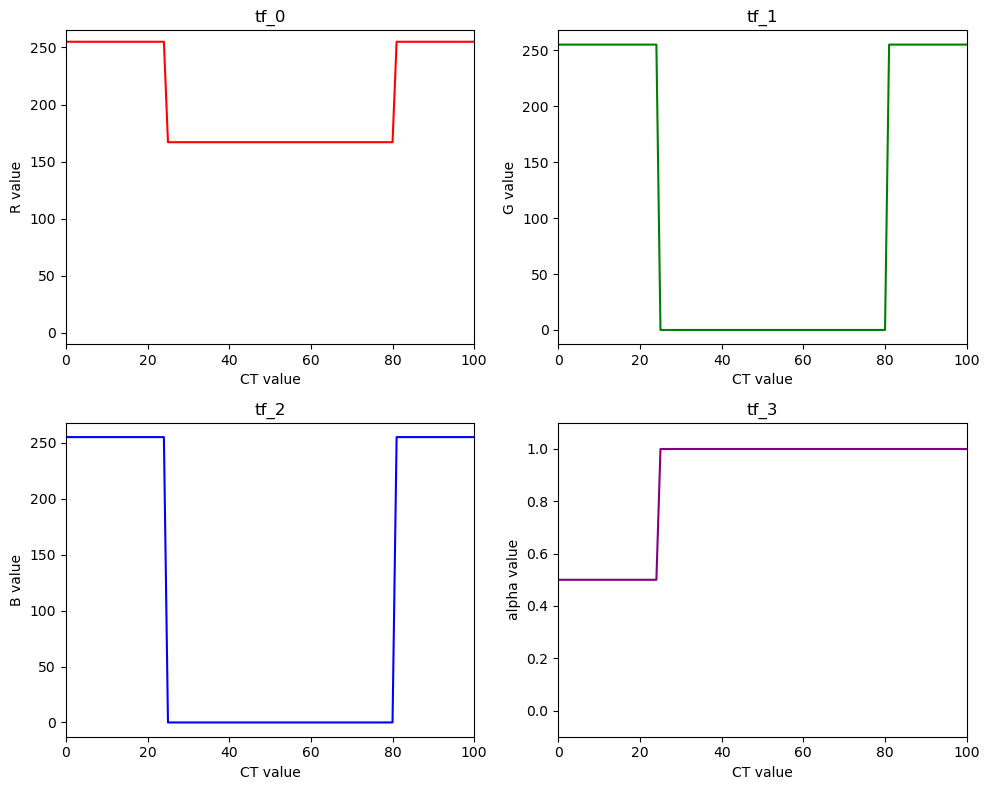

In [288]:
# Define lambda functions
tf_0 = lambda V: 255 if V < 25 or V > 80 else 167
tf_1 = lambda V: 255 if V < 25 or V > 80 else 0
tf_2 = lambda V: 255 if V < 25 or V > 80 else 0
tf_3 = lambda V: 0.5 if V < 25 else 1

# Generate sample points
xs = np.linspace(0, 100, 101)

# Compute ys for each function
ys_0 = [tf_0(x) for x in xs]
ys_1 = [tf_1(x) for x in xs]
ys_2 = [tf_2(x) for x in xs]
ys_3 = [tf_3(x) for x in xs]

# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# Plot the results with adjusted limits
axs[0, 0].plot(xs, ys_0, color='red')
axs[0, 0].set_xlabel("CT value")
axs[0, 0].set_ylabel("R value")
axs[0, 0].set_title("tf_0")
axs[0, 0].set_xlim(0, 100)
axs[0, 0].set_ylim(-10, 265)

axs[0, 1].plot(xs, ys_1, color='green')
axs[0, 1].set_xlabel("CT value")
axs[0, 1].set_ylabel("G value")
axs[0, 1].set_title("tf_1")
axs[0, 1].set_xlim(0, 100)
axs[0, 0].set_ylim(-10, 265)

axs[1, 0].plot(xs, ys_2, color='blue')
axs[1, 0].set_xlabel("CT value")
axs[1, 0].set_ylabel("B value")
axs[1, 0].set_title("tf_2")
axs[1, 0].set_xlim(0, 100)
axs[0, 0].set_ylim(-10, 265)

axs[1, 1].plot(xs, ys_3, color='purple')
axs[1, 1].set_xlabel("CT value")
axs[1, 1].set_ylabel("alpha value")
axs[1, 1].set_title("tf_3")
axs[1, 1].set_xlim(0, 100)
axs[1, 1].set_ylim(-0.1, 1.1)

plt.tight_layout()
plt.show()

(b)

In [304]:
def mip(data, axis):
    """
    Performs Maximum Intensity Projection (MIP) along the specified axis.

    Args:
        data: 3D numpy array containing the volumetric data.
        axis: Axis along which to perform the projection (0 for x, 1 for y, 2 for z).

    Returns:
        2D numpy array containing the MIP projection.
    """
    return np.max(data, axis=axis)

def load_data(data_dir):
    """
    Loads the image data from the specified directory.

    Args:
        data_dir: Path to the directory containing the image files.

    Returns:
        3D numpy array containing the loaded image data.
    """

    def get_slice_number(filename):
        """Extracts the slice number from the filename."""
        try:
            return int(filename.split("slice_")[-1].split(".tif")[0]) 
        except (ValueError, IndexError):
            raise Exception("Extracting slice number from file path failed!")

    image_files = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.startswith("slice_")]
    image_files.sort(key=get_slice_number)  # Sort by slice number

    data = []
    for image_file in image_files:
        print(image_file)
        image = cv2.imread(image_file, cv2.IMREAD_GRAYSCALE)
        data.append(image)

    return np.stack(data, axis=0)

def save_projection(projection, filename):
    """
    Saves the MIP projection to a file.

    Args:
        projection: 2D numpy array containing the MIP projection.
        filename: Path to the file to save the projection to.
    """
    cv2.imwrite(filename, projection)

data_dir = "/Users/piotrblaszyk/Documents/university/MRIGI/igi-70004/cw-2/task-4-data"
data = load_data(data_dir)

# (z, y, x)

projection_x = mip(data, axis=2)
projection_y = mip(data, axis=1)
projection_z = mip(data, axis=0)

save_projection(projection_x, f"{figures_dir}projection_x.tif")
save_projection(projection_y, f"{figures_dir}projection_y.tif")
save_projection(projection_z, f"{figures_dir}projection_z.tif")

/Users/piotrblaszyk/Documents/university/MRIGI/igi-70004/cw-2/task-4-data/slice_1.tif
/Users/piotrblaszyk/Documents/university/MRIGI/igi-70004/cw-2/task-4-data/slice_2.tif
/Users/piotrblaszyk/Documents/university/MRIGI/igi-70004/cw-2/task-4-data/slice_3.tif
/Users/piotrblaszyk/Documents/university/MRIGI/igi-70004/cw-2/task-4-data/slice_4.tif
/Users/piotrblaszyk/Documents/university/MRIGI/igi-70004/cw-2/task-4-data/slice_5.tif
/Users/piotrblaszyk/Documents/university/MRIGI/igi-70004/cw-2/task-4-data/slice_6.tif
/Users/piotrblaszyk/Documents/university/MRIGI/igi-70004/cw-2/task-4-data/slice_7.tif
/Users/piotrblaszyk/Documents/university/MRIGI/igi-70004/cw-2/task-4-data/slice_8.tif
/Users/piotrblaszyk/Documents/university/MRIGI/igi-70004/cw-2/task-4-data/slice_9.tif
/Users/piotrblaszyk/Documents/university/MRIGI/igi-70004/cw-2/task-4-data/slice_10.tif
/Users/piotrblaszyk/Documents/university/MRIGI/igi-70004/cw-2/task-4-data/slice_11.tif
/Users/piotrblaszyk/Documents/university/MRIGI/igi-7

NameError: name 'figures_dir' is not defined

In [ ]:
print(data.shape)

image_file = f"{figures_dir}epipolar-lines.png"
bar = cv2.imread(image_file, cv2.IMREAD_GRAYSCALE)
print(bar.shape)

(2559, 630, 630)
(660, 1570)
